<a href="https://colab.research.google.com/github/zoybathecodess/Digital-Reputation-Score-for-Small-Businesses/blob/main/fake_review_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Core
import pandas as pd
import numpy as np

# NLP
import re
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# XGBoost
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df= pd.read_excel('/content/drive/MyDrive/Colab Notebooks/ScoreShield_12000_Rows_With_Platforms.xlsx')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Platform             12000 non-null  object        
 1   Product_ID           12000 non-null  object        
 2   Product_Category     12000 non-null  object        
 3   Product_Subcategory  12000 non-null  object        
 4   Product_Price        12000 non-null  int64         
 5   Discount_%           12000 non-null  int64         
 6   Stock_Count          12000 non-null  int64         
 7   Review_ID            12000 non-null  object        
 8   Seller_ID            12000 non-null  object        
 9   Rating               12000 non-null  int64         
 10  Review_Text          12000 non-null  object        
 11  Review_Length        12000 non-null  int64         
 12  Sentiment_Score      12000 non-null  float64       
 13  Verified_Purchase    12000 non-

In [7]:
# Convert Fraud_Label to binary
df['fraud_binary'] = df['Fraud_Label'].apply(
    lambda x: 1 if x == 'Fake' else 0
)

df['fraud_binary'].value_counts()

,count
fraud_binary,
0,11685
1,315


In [10]:
binary_map = {'Yes': 1, 'No': 0}

df['Verified_Purchase'] = df['Verified_Purchase'].map(binary_map)
df['Return_Requested'] = df['Return_Requested'].map(binary_map)
df['Damage_Reported'] = df['Damage_Reported'].map(binary_map)

# Encode complaint type
df['Complaint_Type'] = df['Complaint_Type'].fillna('None')
le_complaint = LabelEncoder()
df['Complaint_Type_Enc'] = le_complaint.fit_transform(df['Complaint_Type'])

In [11]:
feature_cols = [
    'Rating',
    'Sentiment_Score',
    'Review_Length',
    'Verified_Purchase',
    'Delivery_Days',
    'Return_Requested',
    'Damage_Reported',
    'Complaint_Type_Enc',
    'IP_Review_Frequency',
    'Device_Reuse_Count',
    'Burst_Review_Flag'
]

X = df[feature_cols]
y = df['fraud_binary']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# Fix Burst_Review_Flag (object → numeric)
df['Burst_Review_Flag'] = df['Burst_Review_Flag'].map({
    'Yes': 1,
    'No': 0
})

In [18]:
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Burst_Review_Flag: object

In [17]:
df['Burst_Review_Flag'] = df['Burst_Review_Flag'].fillna(0)

In [19]:
df.dtypes

,0
Platform,object
Product_ID,object
Product_Category,object
Product_Subcategory,object
Product_Price,int64
Discount_%,int64
Stock_Count,int64
Review_ID,object
Seller_ID,object
Rating,int64


In [20]:
object_cols = df.select_dtypes(include='object').columns
object_cols

Index(['Platform', 'Product_ID', 'Product_Category', 'Product_Subcategory',
       'Review_ID', 'Seller_ID', 'Review_Text', 'Complaint_Type', 'IP_Address',
       'Device_Fingerprint', 'Fraud_Label'],
      dtype='object')

In [21]:
df_numeric = df.drop(columns=object_cols)

In [23]:
selected_features = [
    'Rating',
    'Sentiment_Score',
    'Review_Length',
    'Verified_Purchase',
    'Delivery_Days',
    'Return_Requested',
    'Damage_Reported',
    'Complaint_Type_Enc',
    'IP_Review_Frequency',
    'Device_Reuse_Count',
    'Burst_Review_Flag'
]

In [25]:
X = df[selected_features]
y = df['fraud_binary']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(9600, 11) (2400, 11)
fraud_binary
0    9348
1     252
Name: count, dtype: int64


In [28]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [29]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9754166666666667
ROC-AUC: 0.9883380538066032

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2337
           1       0.53      0.54      0.54        63

    accuracy                           0.98      2400
   macro avg       0.76      0.76      0.76      2400
weighted avg       0.98      0.98      0.98      2400



In [30]:
df['fake_probability'] = xgb_model.predict_proba(X)[:, 1]
df['is_fake'] = (df['fake_probability'] > 0.5).astype(int)

In [31]:
df['review_weight'] = 1 - df['fake_probability']

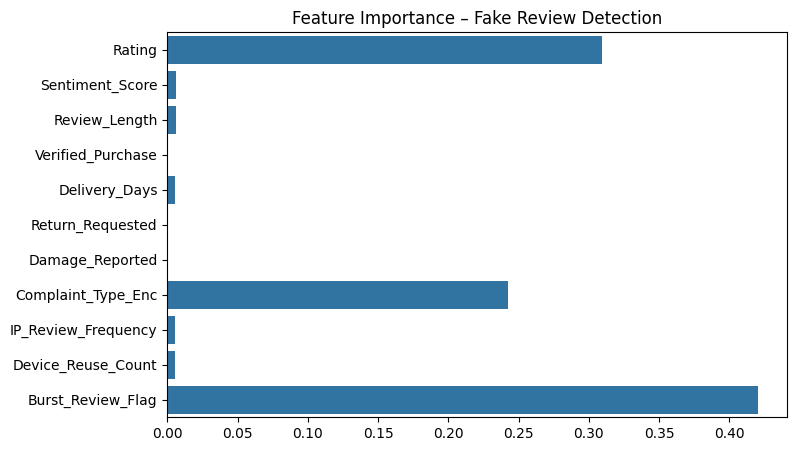

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    x=xgb_model.feature_importances_,
    y=selected_features
)
plt.title("Feature Importance – Fake Review Detection")
plt.show()

In [33]:
drs_df = df[[
    'Seller_ID',
    'Rating',
    'Sentiment_Score',
    'review_weight',
    'is_fake'
]].copy()

In [34]:
drs_df['weighted_rating'] = drs_df['Rating'] * drs_df['review_weight']
drs_df['weighted_sentiment'] = drs_df['Sentiment_Score'] * drs_df['review_weight']

In [35]:
seller_agg = drs_df.groupby('Seller_ID').agg(
    avg_weighted_rating=('weighted_rating', 'mean'),
    avg_weighted_sentiment=('weighted_sentiment', 'mean'),
    review_count=('Seller_ID', 'count'),
    fake_ratio=('is_fake', 'mean')
).reset_index()

In [36]:
seller_agg['rating_norm'] = (seller_agg['avg_weighted_rating'] - 1) / 4

In [37]:
seller_agg['sentiment_norm'] = (seller_agg['avg_weighted_sentiment'] + 1) / 2

In [38]:
import numpy as np

seller_agg['review_count_norm'] = np.log1p(seller_agg['review_count'])
seller_agg['review_count_norm'] /= seller_agg['review_count_norm'].max()

In [39]:
seller_agg['authenticity_score'] = 1 - seller_agg['fake_ratio']

In [40]:
C = seller_agg['rating_norm'].mean()
m = 20  # minimum reviews threshold

seller_agg['bayesian_rating'] = (
    (seller_agg['review_count'] / (seller_agg['review_count'] + m)) * seller_agg['rating_norm']
    + (m / (seller_agg['review_count'] + m)) * C
)

In [41]:
seller_agg['DRS'] = (
    0.35 * seller_agg['bayesian_rating'] +
    0.25 * seller_agg['sentiment_norm'] +
    0.20 * seller_agg['authenticity_score'] +
    0.20 * seller_agg['review_count_norm']
)

In [42]:
seller_agg['reputation_label'] = pd.cut(
    seller_agg['DRS'],
    bins=[0, 0.4, 0.7, 1],
    labels=['Low Reputation', 'Moderate Reputation', 'High Reputation']
)

In [43]:
seller_agg['business_type'] = np.where(
    seller_agg['review_count'] < 50,
    'Small Business',
    'Large Business'
)

In [45]:
seller_agg.sort_values(by='DRS', ascending=False).head(100)

,Seller_ID,avg_weighted_rating,avg_weighted_sentiment,review_count,fake_ratio,rating_norm,sentiment_norm,review_count_norm,authenticity_score,bayesian_rating,DRS,reputation_label,business_type
46,S1040,3.398934,0.534927,10,0.0,0.599733,0.767464,0.814381,1.0,0.511731,0.733848,High Reputation,Small Business
165,S1148,3.748538,0.304144,12,0.0,0.687135,0.652072,0.871116,1.0,0.550007,0.729744,High Reputation,Small Business
7,S1004,3.767922,0.223869,13,0.0,0.691981,0.611935,0.896285,1.0,0.556071,0.726866,High Reputation,Small Business
1170,S703,3.588310,0.155372,15,0.0,0.647077,0.577686,0.941636,1.0,0.544593,0.723356,High Reputation,Small Business
1249,S775,3.499051,0.219198,14,0.0,0.624763,0.609599,0.919717,1.0,0.532391,0.722680,High Reputation,Small Business
...,...,...,...,...,...,...,...,...,...,...,...,...,...
483,S1434,2.333049,0.308792,12,0.0,0.333262,0.654396,0.871116,1.0,0.417305,0.683879,Moderate Reputation,Small Business
1440,S947,2.888336,0.305404,9,0.0,0.472084,0.652702,0.782011,1.0,0.469081,0.683756,Moderate Reputation,Small Business
1153,S689,3.554781,0.157811,9,0.0,0.638695,0.578906,0.782011,1.0,0.520788,0.683405,Moderate Reputation,Small Business
547,S1492,2.749021,0.386646,8,0.0,0.437255,0.693323,0.746229,1.0,0.459023,0.683235,Moderate Reputation,Small Business
